# Part 2
## Fitness Classification Dataset

```text
Dataset: Real-World Style Fitness Classification Dataset (Synthetic)
URL:     https://www.kaggle.com/datasets/muhammedderric/fitness-classification-dataset-synthetic/data
Task:    classification (binary)
Target:  is_fit
```


5. Базові моделі (Dummy, Logistic)
6. Навчання нейронної мережі + регуляризація
7. Оцінка
8. Оптимізація гіперпараметрів
9. Representation learning


In [47]:
# Imports
import os, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.base import BaseEstimator, ClassifierMixin


from dim_viz_student import TSNE as MyTSNE
from nn_multiclass_student import NeuralNetwork

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

In [48]:
# Load Part 1 artifacts
with open('artifacts/part1_data.pkl', 'rb') as f:
    art = pickle.load(f)

X_train, X_val, X_test = art['X_train'], art['X_val'], art['X_test']
y_train, y_val, y_test = art['y_train'], art['y_val'], art['y_test']
FEATURE_NAMES = art['feature_names']

n_features = X_train.shape[1]
print('Shapes:')
for n, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f'  {n:<5s} {X.shape}')
print('n_features =', n_features)

Shapes:
  train (1400, 14)
  val   (300, 14)
  test  (300, 14)
n_features = 14


---
## Частина 5. Базові моделі


### 5.1 Наївний класифікатор

In [49]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy_val = dummy.predict(X_val)
y_proba_dummy_val = dummy.predict_proba(X_val)[:, 1]

dummy_metrics_val = {
    'accuracy':  accuracy_score(y_val, y_pred_dummy_val),
    'precision': precision_score(y_val, y_pred_dummy_val, zero_division=0),
    'recall':    recall_score(y_val, y_pred_dummy_val, zero_division=0),
    'f1':        f1_score(y_val, y_pred_dummy_val, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, y_proba_dummy_val),
}
print('Dummy (most_frequent) — validation:')
for k, v in dummy_metrics_val.items():
    print(f'  {k:<10s} {v:.4f}')

Dummy (most_frequent) — validation:
  accuracy   0.6000
  precision  0.0000
  recall     0.0000
  f1         0.0000
  roc_auc    0.5000


### 5.2 Лінійна модель — Logistic Regression

In [50]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

y_pred_lr_val  = lr.predict(X_val)
y_proba_lr_val = lr.predict_proba(X_val)[:, 1]

lr_metrics_val = {
    'accuracy':  accuracy_score(y_val, y_pred_lr_val),
    'precision': precision_score(y_val, y_pred_lr_val),
    'recall':    recall_score(y_val, y_pred_lr_val),
    'f1':        f1_score(y_val, y_pred_lr_val),
    'roc_auc':   roc_auc_score(y_val, y_proba_lr_val),
}
print('LogisticRegression — validation:')
for k, v in lr_metrics_val.items():
    print(f'  {k:<10s} {v:.4f}')

LogisticRegression — validation:
  accuracy   0.7633
  precision  0.7290
  recall     0.6500
  f1         0.6872
  roc_auc    0.8520


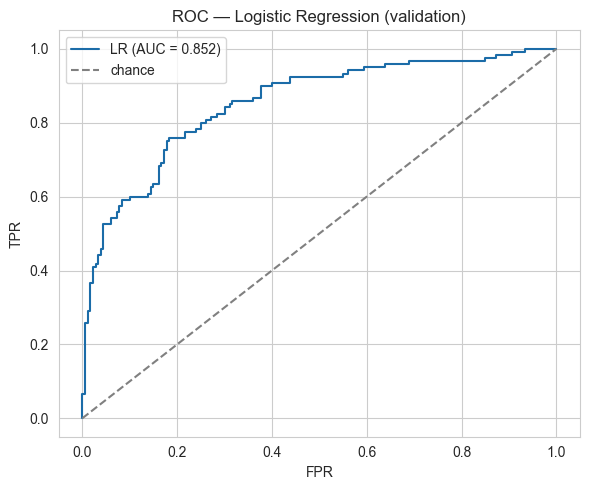

In [51]:
# ROC curve for LR on validation
fpr, tpr, _ = roc_curve(y_val, y_proba_lr_val)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#1b6ca8',
         label=f"LR (AUC = {lr_metrics_val['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='chance')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC — Logistic Regression (validation)')
plt.legend(); plt.tight_layout(); plt.show()

Logistic Regression різко покращує всі метрики над dummy. ROC-AUC ~0.85 говорить, що ознаки добре ранжують. 

---
## Частина 6. Навчання нейронної мережі


### 6.1 Підготовка

In [52]:
# Бінарна класифікація: останній шар — sigmoid, 1 нейрон.
# Цільову не треба one-hot encode'ити (наш NN підтримує sigmoid out).
y_train_b = y_train.astype(int)
y_val_b   = y_val.astype(int)
y_test_b  = y_test.astype(int)
print('y_train share class 1:', y_train_b.mean().round(3))

y_train share class 1: 0.399


### 6.2 Початкова архітектура

In [53]:
nn_base = NeuralNetwork(
    layer_sizes=[n_features, 64, 32, 1],
    activations=['relu', 'relu', 'sigmoid'],
    random_state=RANDOM_STATE,
)
nn_base.fit(X_train, y_train_b, lr=0.05, n_epochs=500, verbose=False)
print('Final training loss:', nn_base.loss_curve_[-1])

Final training loss: 0.4205100360720051


### 6.3 Діагностика навчання

In [54]:
# Базовий NN не пише val loss всередині fit.
# Оцінимо його на val вручну в кінці кожного epoch'у через окремий цикл.
def fit_with_val(model, X_tr, y_tr, X_val, y_val, lr, n_epochs,
                 l2_lambda=0.0, patience=None, verbose=False):
    """Fit-варіант, що пише train+val loss кожну епоху, з опціональним L2 і
    ранньою зупинкою (patience=None вимикає її)."""
    model.loss_curve_ = []
    model.val_loss_curve_ = []
    model.initialise_params()
    L = len(model.layer_sizes) - 1

    best_val = np.inf
    best_state = None
    no_improve = 0
    stopped_at = n_epochs

    for epoch in range(n_epochs):
        A_out, cache = model.forward(X_tr)
        loss = model.compute_loss(A_out, y_tr)
        # L2 penalty added to monitoring (and gradient below)
        if l2_lambda:
            loss += 0.5 * l2_lambda * sum(np.sum(model.params_[f'W{l}']**2)
                                          for l in range(1, L+1))
        model.loss_curve_.append(loss)

        grads = model.backward(y_tr, cache)
        if l2_lambda:
            for l in range(1, L+1):
                grads[f'dW{l}'] += l2_lambda * model.params_[f'W{l}']
        model.update_params(grads, lr)

        A_val, _ = model.forward(X_val)
        val_loss = model.compute_loss(A_val, y_val)
        model.val_loss_curve_.append(val_loss)

        if patience is not None:
            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.copy() for k, v in model.params_.items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    stopped_at = epoch + 1
                    if best_state is not None:
                        model.params_ = best_state
                    break

        if verbose and (epoch % 100 == 0):
            print(f'  epoch {epoch:>4d}  train={loss:.4f}  val={val_loss:.4f}')

    return stopped_at

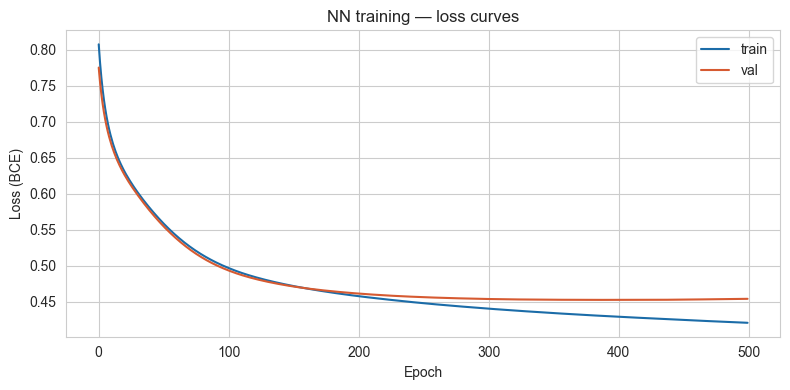

In [55]:
nn_diag = NeuralNetwork(
    layer_sizes=[n_features, 64, 32, 1],
    activations=['relu', 'relu', 'sigmoid'],
    random_state=RANDOM_STATE,
)
fit_with_val(nn_diag, X_train, y_train_b, X_val, y_val_b,
             lr=0.05, n_epochs=500, verbose=False)

plt.figure(figsize=(8, 4))
plt.plot(nn_diag.loss_curve_, label='train', color='#1b6ca8')
plt.plot(nn_diag.val_loss_curve_, label='val', color='#d65a31')
plt.xlabel('Epoch'); plt.ylabel('Loss (BCE)')
plt.title('NN training — loss curves')
plt.legend(); plt.tight_layout(); plt.show()

 Після 150-200 епохи train-loss падає, а val починає рости - модель починає перенавчатись

### 6.4 Вплив регуляризації

In [56]:
def metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

def nn_predict(model, X, threshold=0.5):
    A, _ = model.forward(X)
    proba = A.ravel()
    return (proba >= threshold).astype(int), proba

variants = {}

# базовий — без регуляризації
nn_v1 = NeuralNetwork([n_features, 64, 32, 1], ['relu','relu','sigmoid'], random_state=RANDOM_STATE)
fit_with_val(nn_v1, X_train, y_train_b, X_val, y_val_b, lr=0.05, n_epochs=500)
yhat, p = nn_predict(nn_v1, X_val)
variants['Base']  = (nn_v1, metrics(y_val_b, yhat, p))

# L2
nn_v2 = NeuralNetwork([n_features, 64, 32, 1], ['relu','relu','sigmoid'], random_state=RANDOM_STATE)
fit_with_val(nn_v2, X_train, y_train_b, X_val, y_val_b,
             lr=0.05, n_epochs=500, l2_lambda=1e-3)
yhat, p = nn_predict(nn_v2, X_val)
variants['L2 (1e-3)'] = (nn_v2, metrics(y_val_b, yhat, p))

# Early stopping
nn_v3 = NeuralNetwork([n_features, 64, 32, 1], ['relu','relu','sigmoid'], random_state=RANDOM_STATE)
stop = fit_with_val(nn_v3, X_train, y_train_b, X_val, y_val_b,
                    lr=0.05, n_epochs=500, patience=20)
yhat, p = nn_predict(nn_v3, X_val)
variants['Early stop'] = (nn_v3, metrics(y_val_b, yhat, p))
print(f'  Early-stop ended at epoch {stop}')

print('\nValidation metrics:')
print(pd.DataFrame({k: v[1] for k, v in variants.items()}).T.round(4))

  Early-stop ended at epoch 413

Validation metrics:
            accuracy  precision  recall      f1  roc_auc
Base            0.79     0.7568     0.7  0.7273   0.8606
L2 (1e-3)       0.79     0.7568     0.7  0.7273   0.8606
Early stop      0.79     0.7568     0.7  0.7273   0.8604


In [57]:
best_name = max(variants, key=lambda k: variants[k][1]['f1'])
nn_best, nn_best_val = variants[best_name]
print(f'Best NN variant by val F1: {best_name}')
nn_best_val

Best NN variant by val F1: Base


{'accuracy': 0.79,
 'precision': 0.7567567567567568,
 'recall': 0.7,
 'f1': 0.7272727272727273,
 'roc_auc': np.float64(0.8606018518518519)}

В нашому випадку різниці в точності майже немає

---
## Частина 7. Оцінка моделі (на тестовому наборі)


In [58]:
# 7.1 Збираємо метрики на TEST для трьох моделей
y_pred_dummy_test  = dummy.predict(X_test)
y_proba_dummy_test = dummy.predict_proba(X_test)[:, 1]
dummy_test = metrics(y_test_b, y_pred_dummy_test, y_proba_dummy_test)

y_pred_lr_test  = lr.predict(X_test)
y_proba_lr_test = lr.predict_proba(X_test)[:, 1]
lr_test = metrics(y_test_b, y_pred_lr_test, y_proba_lr_test)

y_pred_nn_test, y_proba_nn_test = nn_predict(nn_best, X_test)
nn_test = metrics(y_test_b, y_pred_nn_test, y_proba_nn_test)

summary = pd.DataFrame({'Dummy': dummy_test, 'LogReg': lr_test, 'NN (best)': nn_test}).T.round(4)
summary

,accuracy,precision,recall,f1,roc_auc
Dummy,0.6000,0.0000,0.0000,0.0000,0.5000
LogReg,0.7800,0.7755,0.6333,0.6972,0.8470
NN (best),0.7833,0.7723,0.6500,0.7059,0.8422


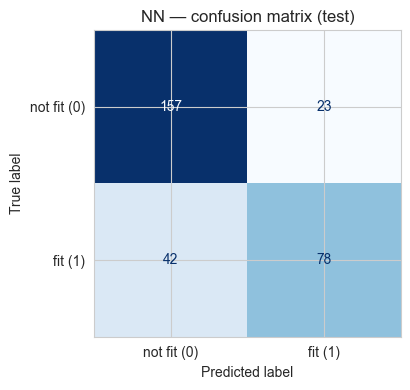

In [59]:
# 7.2 Confusion matrix для NN
cm = confusion_matrix(y_test_b, y_pred_nn_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['not fit (0)', 'fit (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('NN — confusion matrix (test)')
plt.tight_layout(); plt.show()

Нейронна мережа краще розпізнає клас `not_fit`, ніж клас `fit`

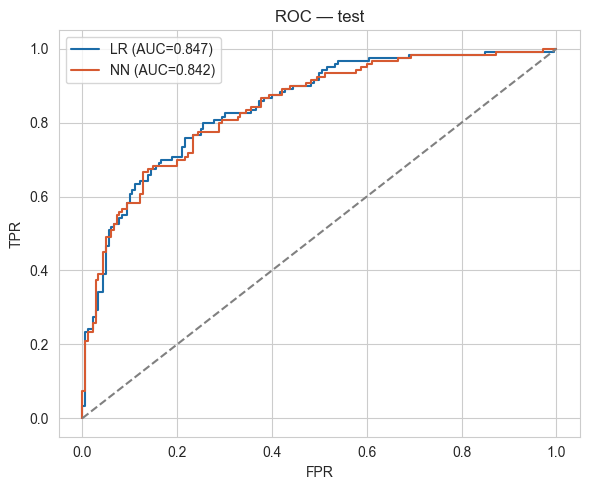

In [60]:
# 7.3 ROC-криві для LR і NN
fpr_lr, tpr_lr, _ = roc_curve(y_test_b, y_proba_lr_test)
fpr_nn, tpr_nn, _ = roc_curve(y_test_b, y_proba_nn_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='#1b6ca8', label=f"LR (AUC={lr_test['roc_auc']:.3f})")
plt.plot(fpr_nn, tpr_nn, color='#d65a31', label=f"NN (AUC={nn_test['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — test')
plt.legend(); plt.tight_layout(); plt.show()

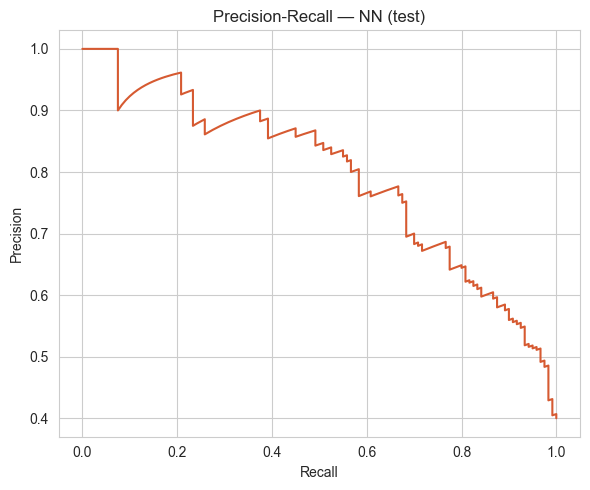

In [61]:
# Precision-Recall curve for NN
prec, rec, _ = precision_recall_curve(y_test_b, y_proba_nn_test)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, color='#d65a31')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall — NN (test)')
plt.tight_layout(); plt.show()

При дисбалансі класів PR-крива є більш показовою, бо напряму оцінює якість роботи з позитивним класом. Вона демонструє, наскільки точними є прогнози `fit` і яку частку реальних `fit`-об’єктів модель знаходить. ROC-крива більше показує загальну здатність розділяти класи, але може виглядати оптимістично при нерівномірному розподілі класів.

---
## Частина 8. Оптимізація гіперпараметрів


### 8.1 sklearn-сумісний wrapper

In [62]:
class NNClassifier(BaseEstimator, ClassifierMixin):
    """sklearn-сумісна обгортка над нашою NeuralNetwork."""
    def __init__(self, layer_sizes=None, activations=None,
                 lr=0.01, n_epochs=500, random_state=42):
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self._model = NeuralNetwork(
            layer_sizes=self.layer_sizes,
            activations=self.activations,
            random_state=self.random_state,
        )
        self._model.fit(X, y.astype(int), lr=self.lr,
                        n_epochs=self.n_epochs, verbose=False)
        return self

    def predict_proba(self, X):
        A, _ = self._model.forward(X)
        proba = A.ravel()
        return np.stack([1.0 - proba, proba], axis=1)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

    def score(self, X, y):
        return f1_score(y, self.predict(X))

### 8.2 Пошук по сітці

Адаптуємо простір під бінарну задачу — фінальна активація `sigmoid`, останній шар має 1 нейрон.

In [63]:
n_out = 1  # binary

param_distributions = {
    'layer_sizes': [
        [n_features, 32, n_out],
        [n_features, 64, n_out],
        [n_features, 64, 32, n_out],
        [n_features, 128, 64, n_out],
        [n_features, 128, 64, 32, n_out],
    ],
    'activations': [
        ['relu', 'sigmoid'],
        ['tanh', 'sigmoid'],
        ['relu', 'relu', 'sigmoid'],
        ['tanh', 'tanh', 'sigmoid'],
        ['relu', 'relu', 'relu', 'sigmoid'],
    ],
    'lr':       [0.0001, 0.001, 0.005, 0.01, 0.05],
    'n_epochs': [300, 500, 1000],
}

base = NNClassifier(layer_sizes=[n_features, 64, 1],
                    activations=['relu', 'sigmoid'],
                    lr=0.01, n_epochs=300, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    base, param_distributions=param_distributions,
    n_iter=20, cv=cv, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0)

t0 = time.time()
search.fit(X_train, y_train_b)
print(f'Search time: {time.time()-t0:.1f}s')
print('Best score (CV f1_macro):', search.best_score_)
print('Best params:', search.best_params_)

Search time: 29.8s
Best score (CV f1_macro): 0.7747410360346331
Best params: {'n_epochs': 500, 'lr': 0.01, 'layer_sizes': [14, 128, 64, 1], 'activations': ['tanh', 'tanh', 'sigmoid']}


### 8.3 Аналіз результатів

In [64]:
results = pd.DataFrame(search.cv_results_)
top5 = results.sort_values('mean_test_score', ascending=False).head(5)
top5_show = top5[['mean_test_score', 'std_test_score',
                  'param_layer_sizes', 'param_activations',
                  'param_lr', 'param_n_epochs']].copy()
top5_show.columns = ['mean_f1m', 'std_f1m', 'layer_sizes', 'activations', 'lr', 'n_epochs']
top5_show.reset_index(drop=True)

,mean_f1m,std_f1m,layer_sizes,activations,lr,n_epochs
0,0.774741,0.003268,"[14, 128, 64, 1]","[tanh, tanh, sigmoid]",0.0100,500
1,0.770274,0.007319,"[14, 64, 1]","[tanh, sigmoid]",0.0100,1000
2,0.743863,0.006456,"[14, 128, 64, 1]","[tanh, tanh, sigmoid]",0.0010,500
3,0.458764,0.000769,"[14, 64, 1]","[relu, sigmoid]",0.0001,300
4,0.448537,0.006020,"[14, 32, 1]","[tanh, sigmoid]",0.0001,500


In [65]:
# Навчаємо найкращу на train+val разом
X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train_b, y_val_b])

best_params = search.best_params_
best_nn_search = NNClassifier(**best_params)
best_nn_search.fit(X_trval, y_trval)

y_pred_search_test  = best_nn_search.predict(X_test)
y_proba_search_test = best_nn_search.predict_proba(X_test)[:, 1]
search_test = metrics(y_test_b, y_pred_search_test, y_proba_search_test)

print('Tuned NN — test:')
for k, v in search_test.items():
    print(f'  {k:<10s} {v:.4f}')

print('\nBaseline NN (Part 6 best) — test:')
for k, v in nn_test.items():
    print(f'  {k:<10s} {v:.4f}')

Tuned NN — test:
  accuracy   0.7567
  precision  0.7640
  recall     0.5667
  f1         0.6507
  roc_auc    0.8426

Baseline NN (Part 6 best) — test:
  accuracy   0.7833
  precision  0.7723
  recall     0.6500
  f1         0.7059
  roc_auc    0.8422


---
## Частина 9. Representation learning


### 9.1 Витягнення прихованих активацій

In [66]:
# Беремо найкращу модель і витягуємо активації передостаннього шару
def hidden_activations(nn, X, layer_idx=None):
    """Return activations of the layer at index `layer_idx` (1-based).
    If None → останній прихований шар (передостанній за номером)."""
    _, cache = nn.forward(X)
    L = len(nn.layer_sizes) - 1
    if layer_idx is None:
        layer_idx = L - 1  # last hidden
    return cache[f'A{layer_idx}']

# nn_best (з Part 6) і tuned (best_nn_search._model) — оберемо tuned, як кращу
chosen_nn = best_nn_search._model
H_train = hidden_activations(chosen_nn, X_train)
H_val   = hidden_activations(chosen_nn, X_val)
H_test  = hidden_activations(chosen_nn, X_test)
print('Hidden activations shape (test):', H_test.shape)

Hidden activations shape (test): (300, 64)


### 9.2 Порівняння просторів — t-SNE

In [67]:
X_tsne_in = X_test
H_tsne_in = H_test
y_tsne = y_test_b

n_tsne = X_test.shape[0]

print(f'Using all available test samples for t-SNE: {n_tsne}')

print('Running t-SNE on raw features...')
ts1 = MyTSNE(
    n_components=2,
    perplexity=30,
    n_iter=400,
    learning_rate=200.0,
    momentum=0.8,
    random_state=RANDOM_STATE
)

Y_raw = ts1.fit_transform(X_tsne_in)

print(f'  final KL raw = {ts1.kl_curve_[-1]:.4f}')


print('Running t-SNE on learned representations...')
ts2 = MyTSNE(
    n_components=2,
    perplexity=30,
    n_iter=400,
    learning_rate=200.0,
    momentum=0.8,
    random_state=RANDOM_STATE
)

Y_h = ts2.fit_transform(H_tsne_in)

print(f'  final KL hidden = {ts2.kl_curve_[-1]:.4f}')

Using all available test samples for t-SNE: 300
Running t-SNE on raw features...
  final KL raw = 0.9597
Running t-SNE on learned representations...
  final KL hidden = 0.8443


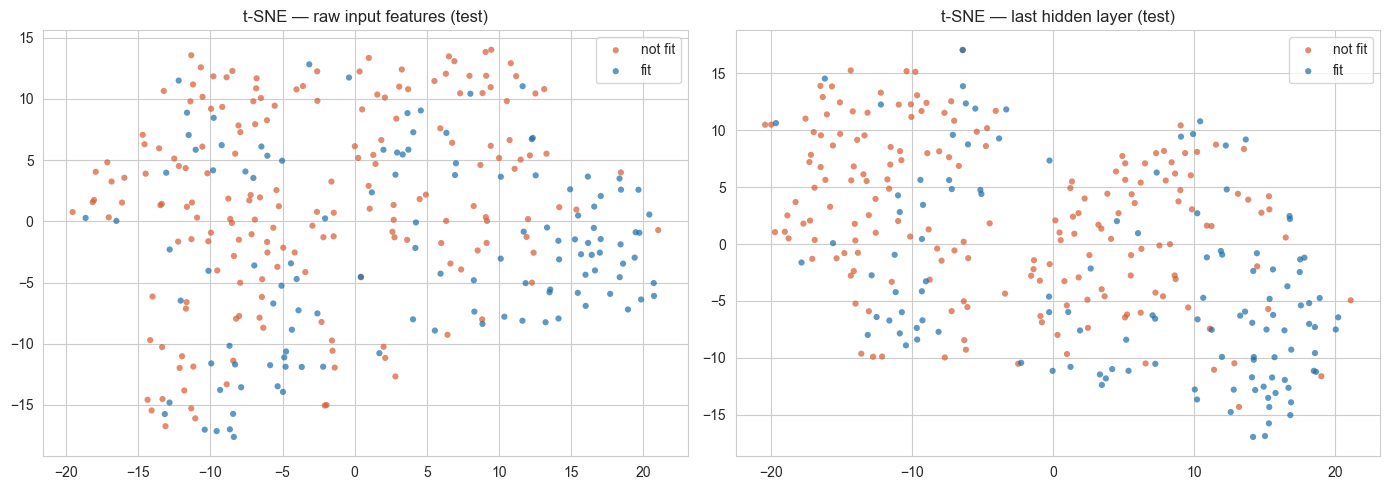

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Y, title in [(axes[0], Y_raw, 't-SNE — raw input features (test)'),
                     (axes[1], Y_h,   't-SNE — last hidden layer (test)')]:
    for cls, color, label in [(0, '#d65a31', 'not fit'), (1, '#1b6ca8', 'fit')]:
        mask = y_tsne == cls
        ax.scatter(Y[mask, 0], Y[mask, 1], c=color, alpha=0.7,
                   edgecolors='none', label=label, s=20)
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

 Якщо у вивченому просторі точки одного класу зливаються в чіткіші скупчення з мінімальним перекриттям - мережа краще навчилась розділяти класи. На цьому датасеті видно певні ущільнення, і на 2 графіку зрозуміліше розділення

### 9.3 Кількісна оцінка — linear probe

In [69]:
# Окремий LR на сирих ознаках і на активаціях
lr_raw = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_raw.fit(X_train, y_train_b)

y_pred_raw = lr_raw.predict(X_test)
y_proba_raw = lr_raw.predict_proba(X_test)[:, 1]

acc_raw_test = lr_raw.score(X_test, y_test_b)
f1_raw_test = f1_score(y_test_b, y_pred_raw, zero_division=0)
auc_raw_test = roc_auc_score(y_test_b, y_proba_raw)



lr_h = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_h.fit(H_train, y_train_b)

y_pred_h = lr_h.predict(H_test)
y_proba_h = lr_h.predict_proba(H_test)[:, 1]

acc_h_test = lr_h.score(H_test, y_test_b)
f1_h_test = f1_score(y_test_b, y_pred_h, zero_division=0)
auc_h_test = roc_auc_score(y_test_b, y_proba_h)

probe = pd.DataFrame({
    'representation': ['raw input (after pipeline)', 'NN last hidden layer'],
    'LR test accuracy': [acc_raw_test, acc_h_test],
    'LR test ROC-AUC':  [auc_raw_test, auc_h_test],
    'LR test f1': [f1_raw_test, f1_h_test],
}).round(4)
probe

,representation,LR test accuracy,LR test ROC-AUC,LR test f1
0,raw input (after pipeline),0.7800,0.8470,0.6972
1,NN last hidden layer,0.7733,0.8406,0.6881


LR на сирих ознаках дає трохи вищі accuracy / F1 / ROC-AUC, ніж LR на активаціях прихованого шару.

---
## Підсумок

Найвищі показники серед усіх експериментів показала **Base NN**.
| Модель | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Dummy | 0.600 | 0.000 | 0.500 |
| LogReg | 0.780 | 0.697 | 0.847 |
| NN (manual best) | 0.783 | 0.705 | 0.842 |
| NN (tuned) | 0.756 | 0.650 | 0.842 |

